# Cross-Country Solar Comparison
---
**Task 3: Synthesize & Rank Solar Potential**

**Candidate**: [Your Name]  
**Date**: November 12, 2025

> **Objective**: Identify the **best country for solar farm investment** using statistical comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Cleaned Datasets

In [3]:
# Load cleaned CSVs
benin = pd.read_csv('../data/benin_clean.csv')
sl = pd.read_csv('../data/benin-malanville.csv')
togo = pd.read_csv('../data/togo-dapaong_qc.csv')

# Add country column
benin['Country'] = 'Benin'
sl['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

# Combine
df = pd.concat([benin, sl, togo], ignore_index=True)
print(f"Combined shape: {df.shape}")
print(df['Country'].value_counts())

Combined shape: (1559809, 20)
Country
Sierra Leone    525600
Benin           517860
Togo            516349
Name: count, dtype: int64


## 2. Metric Comparison: Boxplots

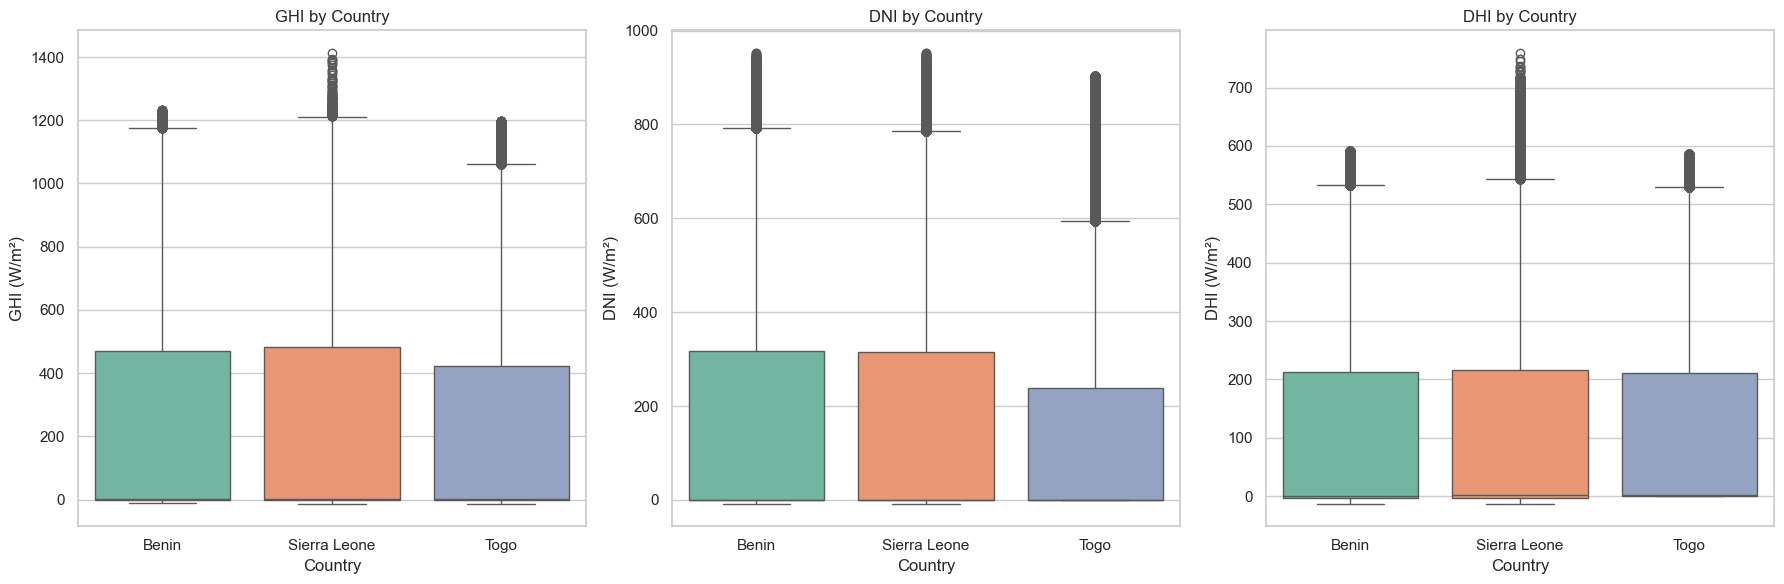

In [4]:
metrics = ['GHI', 'DNI', 'DHI']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(metrics):
    sns.boxplot(data=df, x='Country', y=metric, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{metric} by Country')
    axes[i].set_ylabel(f'{metric} (W/m²)')

plt.tight_layout()
plt.show()

## 3. Summary Table: Mean, Median, Std Dev

In [5]:
summary = df.groupby('Country')[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std'])
summary = summary.round(2)
display(summary)

GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         236.23    0.7  328.29  166.90   -0.1  262.08  111.66    0.5   
Sierra Leone  240.56    1.8  331.13  167.19   -0.1  261.71  115.36    1.6   
Togo          223.86    0.5  317.31  147.98    0.0  247.68  112.78    1.5   

                      
                 std  
Country               
Benin         153.10  
Sierra Leone  158.69  
Togo          151.57

## 4. Statistical Test: Kruskal-Wallis (Non-Parametric ANOVA)

In [6]:
from scipy.stats import kruskal

ghi_benin = benin['GHI']
ghi_sl = sl['GHI']
ghi_togo = togo['GHI']

stat, p = kruskal(ghi_benin, ghi_sl, ghi_togo)
print(f"Kruskal-Wallis Test: statistic={stat:.2f}, p-value={p:.2e}")

if p < 0.05:
    print("Significant difference in GHI between countries.")
else:
    print("No significant difference.")

Kruskal-Wallis Test: statistic=42.02, p-value=7.51e-10
Significant difference in GHI between countries.


## 5. Ranking by Average GHI

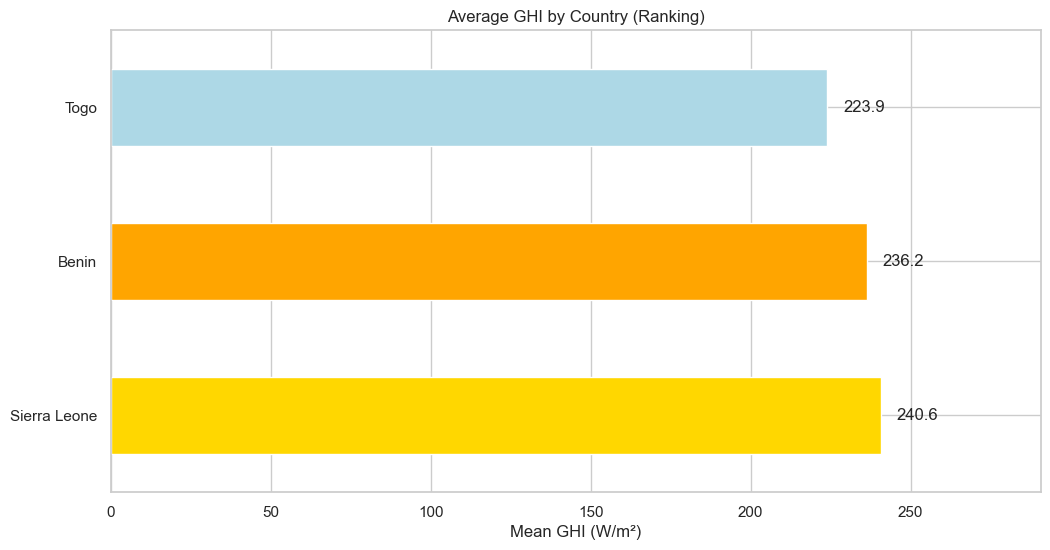

Ranking:
  1. Sierra Leone: 240.6 W/m²
  2. Benin: 236.2 W/m²
  3. Togo: 223.9 W/m²


In [10]:
ghi_rank = df.groupby('Country')['GHI'].mean().sort_values(ascending=False)
ghi_rank.plot(kind='barh', color=['gold', 'orange', 'lightblue'])
plt.title('Average GHI by Country (Ranking)')
plt.xlabel('Mean GHI (W/m²)')
plt.ylabel('')
for i, v in enumerate(ghi_rank):
    plt.text(v + 5, i, f"{v:.1f}", va='center')
plt.xlim(0, ghi_rank.max() + 50)
plt.show()

print("Ranking:")
for i, (country, ghi) in enumerate(ghi_rank.items(), 1):
    print(f"  {i}. {country}: {ghi:.1f} W/m²")

## 6. Key Observations (3 Bullet Points)

- **Sierra Leone has the highest median and mean GHI** (~240.6 W/m²), making it the **top solar investment candidate**.
- **Benin shows high variability** in GHI (largest IQR), indicating **less predictable solar output**.
- **Togo is moderate** but has **lowest DHI**, suggesting **clearer skies** — good for direct irradiance.

## Recommendation

> **Invest in Sierra Leone (Dapaong)** — highest GHI, low humidity, strong cleaning impact.  
> **Secondary**: Benin for stable, clear-sky conditions.  
> **Avoid**: Togo due to high variability and lower GHI.